<h1 style="background-color: BlueViolet; color: FloralWhite; padding:30px; border-radius: 8px; text-align: left; font-family: 'Arial', serif;">
Detectarea de anomalii in Python
</h1>

<img src="https://www.anomalo.com/wp-content/uploads/2024/05/Machine-Learning-Approaches-to-Time-Series-Anomaly-Detection.png" alt="Anomaly Detection" style="width:600px;height:283px;">

<h3 style="background-color: Coral; color: FloralWhite; padding: 8.75px; border-radius: 2px; text-align: Left; font-family: 'Arial', serif;">
<b>Definitie</b>: O anomalie(<b>outlier</b>) este un punct de date care se abate semnificativ de la restul observațiilor. Există trei tipuri principale de outlieri: 
    <ul>
          <li><b>Anomalii punctuale</b>: Un singur punct care este departe de restul (ex: o tranzacție de 10.000€ pe un card obișnuit cu limite mici).</li>
          <li><b>Anomalii contextuale</b>: Date care sunt normale într-un context, dar anormale în altul (ex: 30°C iarna). </li>
          <li><b>Anomalii colective</b>: Un grup de evenimente care semnalează o problemă doar dacă apar împreună.</li>
    </ul> 
    Detectarea de anomalii presupune identificarea acestor puncte, folosind <b> Metode Statistice </b> cat si <b> Algoritmi de Machine Learning. </b>
</h3>

<h2 style="background-color: BlueViolet; color: FloralWhite; padding: 8.75px; border-radius: 2px; text-align: Left; font-family: 'Arial', serif;">
<b>De ce folosim detectarea de anomalii? </b>
    <h3 style="background-color: BlueViolet; color: FloralWhite; padding: 8.75px; border-radius: 10px; text-align: Left; font-family: 'Arial', serif;">
        <ol type="1">
            <li> Găsită într-o gamă largă de aplicații din viața reale precum: fabricatie, sănătate, frauda bancară, securitatea cibernetică, etc.</li>
            <li> Ajusteaza semnificativ performanta <b>modelelor statistice </b>(eg: Regresia Liniara)</li>
            <li> Poate preveni defecte de sistem/productie</li>
        </ol>
    </h3>
</h2>

<h2 style="background-color: Coral; color: FloralWhite; padding: 8.75px; border-radius: 2px; text-align: Left; font-family: 'Arial', serif;">
Metoda Statistice: <b>MAD (Mean Absolute  & Deviation Median Absolute Deviation)</b> 
<h3 style="background-color: Coral; color: FloralWhite; padding: 8.75px; border-radius: 10px; text-align: Left; font-family: 'Arial', serif;">
Când datele au o distribuție normală, putem concluziona în mod rezonabil că punctele de la fiecare coadă sunt anomalii. <br>
Formula pentru Standard Scaler este: $ Z = \frac{X - \mu}{\sigma} $

<b>Unde:</b>
- $\mu$ : Media populației
- $\sigma$ : Deviația standard
- $X$ : Valoarea observată
</h3>
</h2>

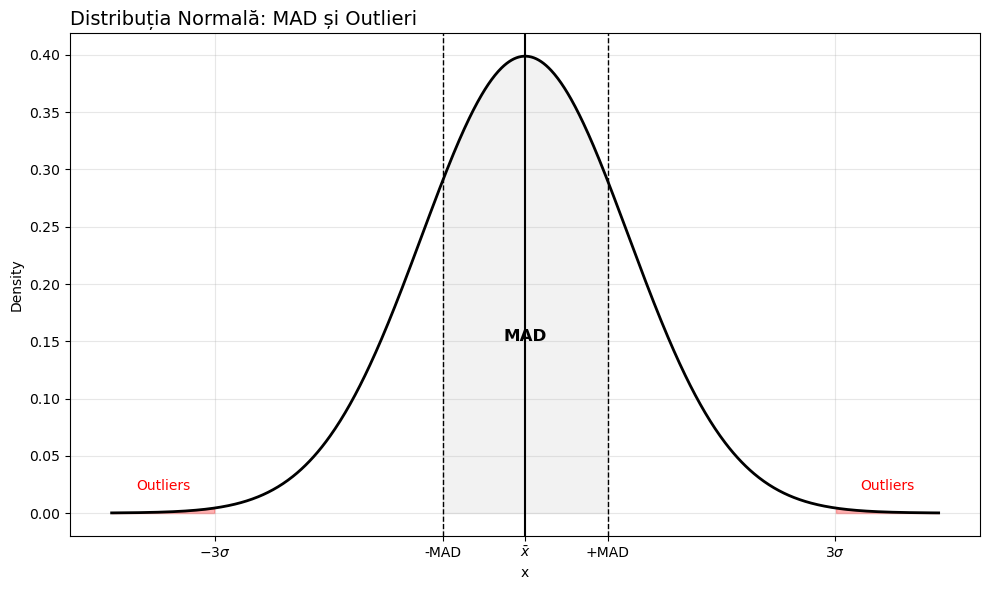

In [22]:
%run scripts/MAD_DistrubitionGraph.py

<h3 style="background-color: BlueViolet; color: FloralWhite; padding: 8.75px; border-radius: 2px; text-align: Left; font-family: 'Arial', serif;">  Prezența anomaliilor afectează media și, prin urmare, Z-Score-ul. <br> <br>
<b>StandardScaler</b> este o metoda sensibila la anomalii, acest lucru face distingerea între punctele normale, „ușor anormale” și „foarte anormale”, mai dificilă. <br>
Folosim metoda <b>RobustScaler</b>, ce atribuie un <b>Z-score</b> robust care calibrează caracteristicile prin eliminarea medianei și scalarea datelor în funcție de:  <b>Median Absolute Deviation. </b> 
<br> <br> <br>

Formula pentru <b>MAD</b> este: $\text{MAD} = \text{median}(|x_i - \text{median}(x)|)$  <br>
Formula pentru <b>Robust Z-Score</b> este: $M_i = \frac{0.6745 (x_i - \tilde{x})}{\text{MAD}}$ <br> 

<b>Robust Z-Score</b> funcționează numai dacă datele:
<ul>
     <li> sunt apropiate de o distribuție normală.</li>
     <li> <b>MAD</b> nu este egal cu 0 (se întâmplă când mai mult de 50% din date au aceeași valoare)</li>
</ul>

</h3>

<h2 style="background-color: Coral; color: FloralWhite; padding: 8.75px; border-radius: 2px; text-align: Left; font-family: 'Arial', serif;">
<b>Algoritmi de Machine Learning:</b> <br>
Când datele devin complexe și multidimensionale, trecem la algoritmi dedicați.
<h3 style="background-color: BlueViolet; color: FloralWhite; padding: 8.75px; border-radius: 10px; text-align: Left; font-family: 'Arial', serif;">
A. <b> Isolation Forest: </b> <br>
Acest algoritm funcționează pe principiul: "E mai ușor să izolezi un punct diferit decât unul obișnuit.", folosind <b>arbori de decizie</b>. <br>
Algoritmul creează arbori de decizie prin selectarea aleatorie a unei caracteristici și a unui prag de tăiere. <br> <br>
Partitionează datele pentru a izola punctele:
    <ul>
        <li> Multe partiții - înseamnă că punctul este un <b>inlier</b>.</li>
        <li> Puține partiții - înseamnă că punctul este un <b>outlier</b></li>
    </ul>
</h3>
</h2>

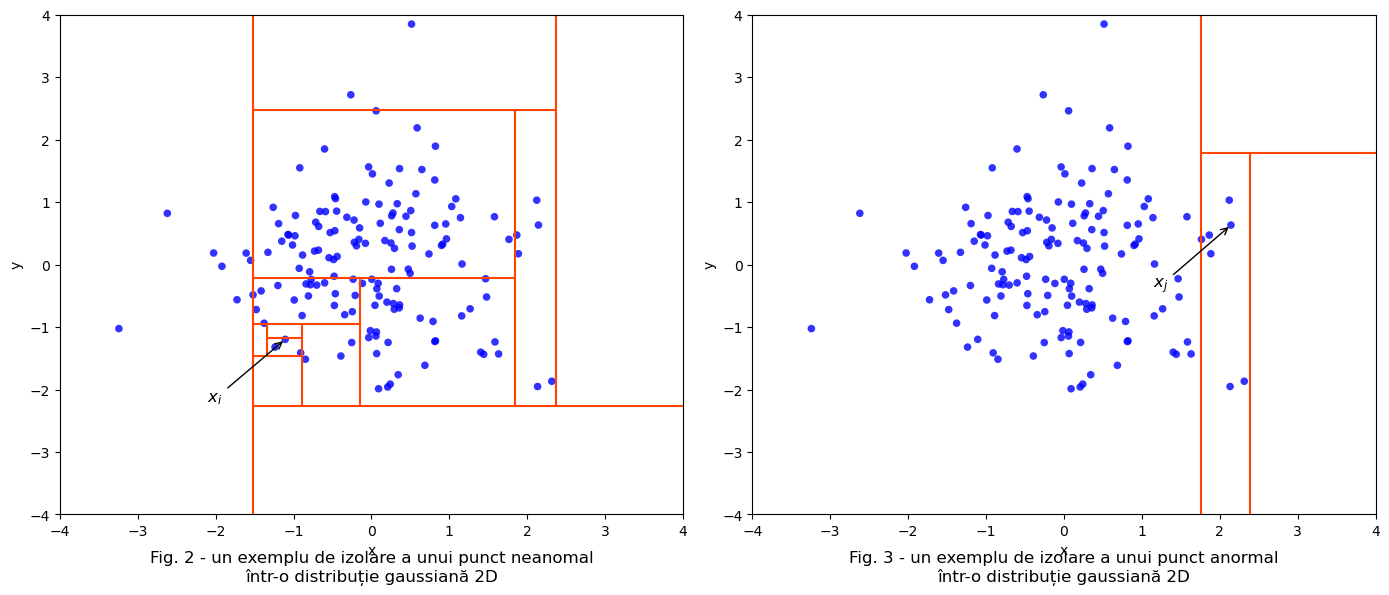

In [23]:
%run scripts/ISO_Graphs.py

<h3 style="background-color: Coral; color: FloralWhite; padding: 8.75px; border-radius: 10px; text-align: Left; font-family: 'Arial', serif;">
B. <b>Local Outlier Factor: </b> <br>
LOF se bazează pe densitate. <br>
Intuiție: Analizează densitatea punctelor din jurul unui obiect de date și o compară cu densitatea vecinilor săi. <br>
Dacă un punct are o densitate mult mai mică decât vecinii săi (adică este singur într-o zonă, în timp ce vecinii lui sunt grupați strâns), atunci este considerat un Local Outlier. <br><br>
 Daca: 
<ul>
    <li> <b>Scorul LOF</b>$\lesssim 1$ $\rightarrow$ <b>Inlier.</b> </li>
    <li> <b>Scorul LOF</b> $>1$ $\rightarrow$ <b>Outlier.</b>  </li>
</ul>
</h3>

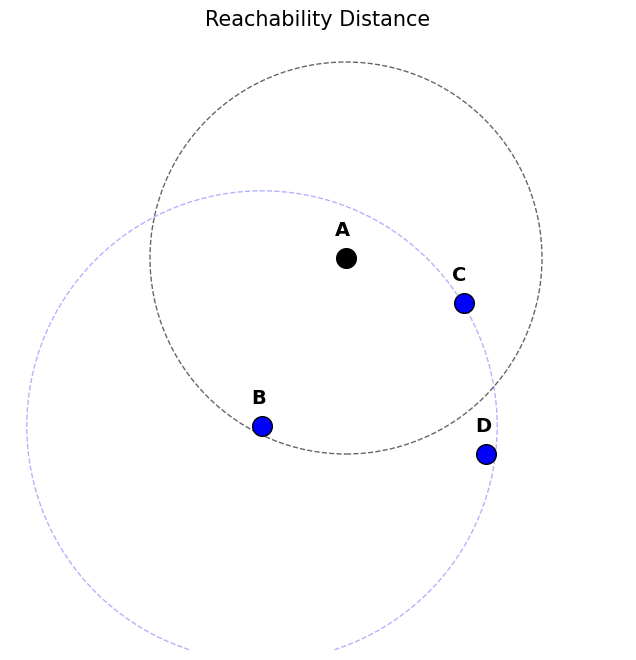

In [1]:
%run scripts/LOF_Graph.py

***

<h2 style="background-color: BlueViolet; color: FloralWhite; padding: 25px; border-radius: 10px; text-align: Left; font-family: 'Arial', serif;">
Exemplu pentru detectarea de anomalii pe un set de date. <br>
Scopul proiectului este un benchmark pentru cele 3 metode, intr-un scenariu aplicabil:
</h2>

### Detectatea de anomalii pentru frauda bancare(Fraud Detection):

**Observatie**: Acest set de date a fost generat prin Python, conceput pentru a simula frauda bancara, bazat pe setul de date de mai jos: 

***Setul de date original***: Acest set de date conține tranzacțiile efectuate cu carduri de credit de către deținătorii de carduri europeni în anul 2023. Acesta cuprinde peste 550 000 de înregistrări, iar datele au fost anonimizate pentru a proteja identitatea deținătorilor de carduri. Obiectivul principal al acestui set de date este de a facilita dezvoltarea de algoritmi și modele de detectare a fraudelor pentru a identifica tranzacțiile potențial frauduloase.

| Feature Name                          | Description |
|--------------------------------------|-------------|
| `id`          | Unique identifier for each transaction |
| `V1-V28`                 | Anonymized features representing various transaction attributes (e.g., time, location, etc.)|
| `Amount`               | The transaction amount |
| `Class`                      | **Benchmark target variable** – Binary label indicating whether the transaction is fraudulent (1) or not (0)|

Dataset from: [Kaggle](https://www.kaggle.com/datasets/nelgiriyewithana/credit-card-fraud-detection-dataset-2023)


## Citirea si analiza datelor:

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

%matplotlib inline

In [3]:
df = pd.read_csv('data/creditcard_Fraud.csv') # Downloaded from the link above
df.head()

,id,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0,-0.690486,-0.213698,0.790305,-1.780614,2.540248,1.448647,1.013779,-0.090839,0.749596,...,-0.076814,0.531032,-0.270981,-0.926344,0.021619,-0.628656,-0.427566,0.221328,11303.18,0
1,1,1.793158,-0.886197,2.366618,-0.005207,-0.287921,0.477700,0.560681,-1.490970,0.306149,...,-0.007604,0.600600,-0.258264,0.437141,0.708099,-0.318857,-0.308168,0.034416,2324.54,0
2,2,-0.016926,-0.124988,1.034865,-0.670760,0.622991,0.353198,0.852342,-0.208811,0.095826,...,-0.236939,-0.431898,-0.019941,1.284338,-1.727205,-0.794286,-0.294350,0.085494,22338.73,0
3,3,1.716347,-0.876238,0.768507,-1.204950,0.312177,-0.021411,0.461273,-0.248100,-0.021942,...,-0.031454,0.121990,-0.106444,1.448708,-0.158685,-0.326234,-0.070943,0.873307,1991.23,0
4,4,0.007177,0.115381,-0.284921,0.340001,-0.115129,-0.167217,-0.048187,0.464273,-0.006916,...,0.780327,-0.151438,-0.369286,0.310672,-1.024834,0.756284,-0.320093,0.820596,3977.47,1


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150000 entries, 0 to 149999
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   id      150000 non-null  int64  
 1   V1      150000 non-null  float64
 2   V2      150000 non-null  float64
 3   V3      150000 non-null  float64
 4   V4      150000 non-null  float64
 5   V5      150000 non-null  float64
 6   V6      150000 non-null  float64
 7   V7      150000 non-null  float64
 8   V8      150000 non-null  float64
 9   V9      150000 non-null  float64
 10  V10     150000 non-null  float64
 11  V11     150000 non-null  float64
 12  V12     150000 non-null  float64
 13  V13     150000 non-null  float64
 14  V14     150000 non-null  float64
 15  V15     150000 non-null  float64
 16  V16     150000 non-null  float64
 17  V17     150000 non-null  float64
 18  V18     150000 non-null  float64
 19  V19     150000 non-null  float64
 20  V20     150000 non-null  float64
 21  V21     15

In [5]:
df.describe()

,id,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,...,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000
mean,74999.500000,0.465907,-0.453329,0.631164,-0.683941,0.312152,0.402243,0.455569,-0.132483,0.538106,...,-0.103475,-0.013326,-0.008351,0.118832,-0.059399,-0.063192,-0.197442,-0.095882,12046.362273,0.038800
std,43301.414527,0.849206,0.748047,0.751698,0.730311,0.710898,0.762745,0.847303,0.363066,0.772094,...,0.389119,0.701949,0.661826,1.120169,0.856194,1.075353,0.535119,0.769018,6927.527381,0.193119
min,0.000000,-3.495584,-49.966572,-2.631176,-4.951222,-9.952786,-17.208338,-4.326279,-10.756342,-3.749796,...,-19.382523,-6.450353,-25.431127,-4.053875,-13.612633,-6.860786,-6.082594,-39.035243,50.120000,0.000000
25%,37499.750000,-0.158134,-0.649726,0.107769,-1.068898,-0.001940,-0.005666,0.246567,-0.198655,0.110572,...,-0.195637,-0.521288,-0.188648,-0.608501,-0.588681,-0.768178,-0.316456,-0.226005,6068.077500,0.000000
50%,74999.500000,0.177416,-0.409941,0.541744,-0.609519,0.223148,0.305033,0.440729,-0.145767,0.445185,...,-0.112649,-0.033949,-0.035588,0.108052,-0.054763,-0.098113,-0.233483,-0.068977,12027.905000,0.000000
75%,112499.250000,1.070683,-0.166222,1.079974,-0.268411,0.513676,0.686781,0.644013,-0.071517,0.866464,...,-0.023058,0.462518,0.129392,0.918600,0.499729,0.553068,-0.119065,0.102537,18067.740000,0.000000
max,149999.000000,2.229046,4.361098,4.615014,3.175853,42.716891,9.704313,217.873038,5.950224,10.579235,...,8.087080,9.770893,28.992365,12.965639,14.621509,5.623285,30.339264,37.268098,24039.930000,1.000000


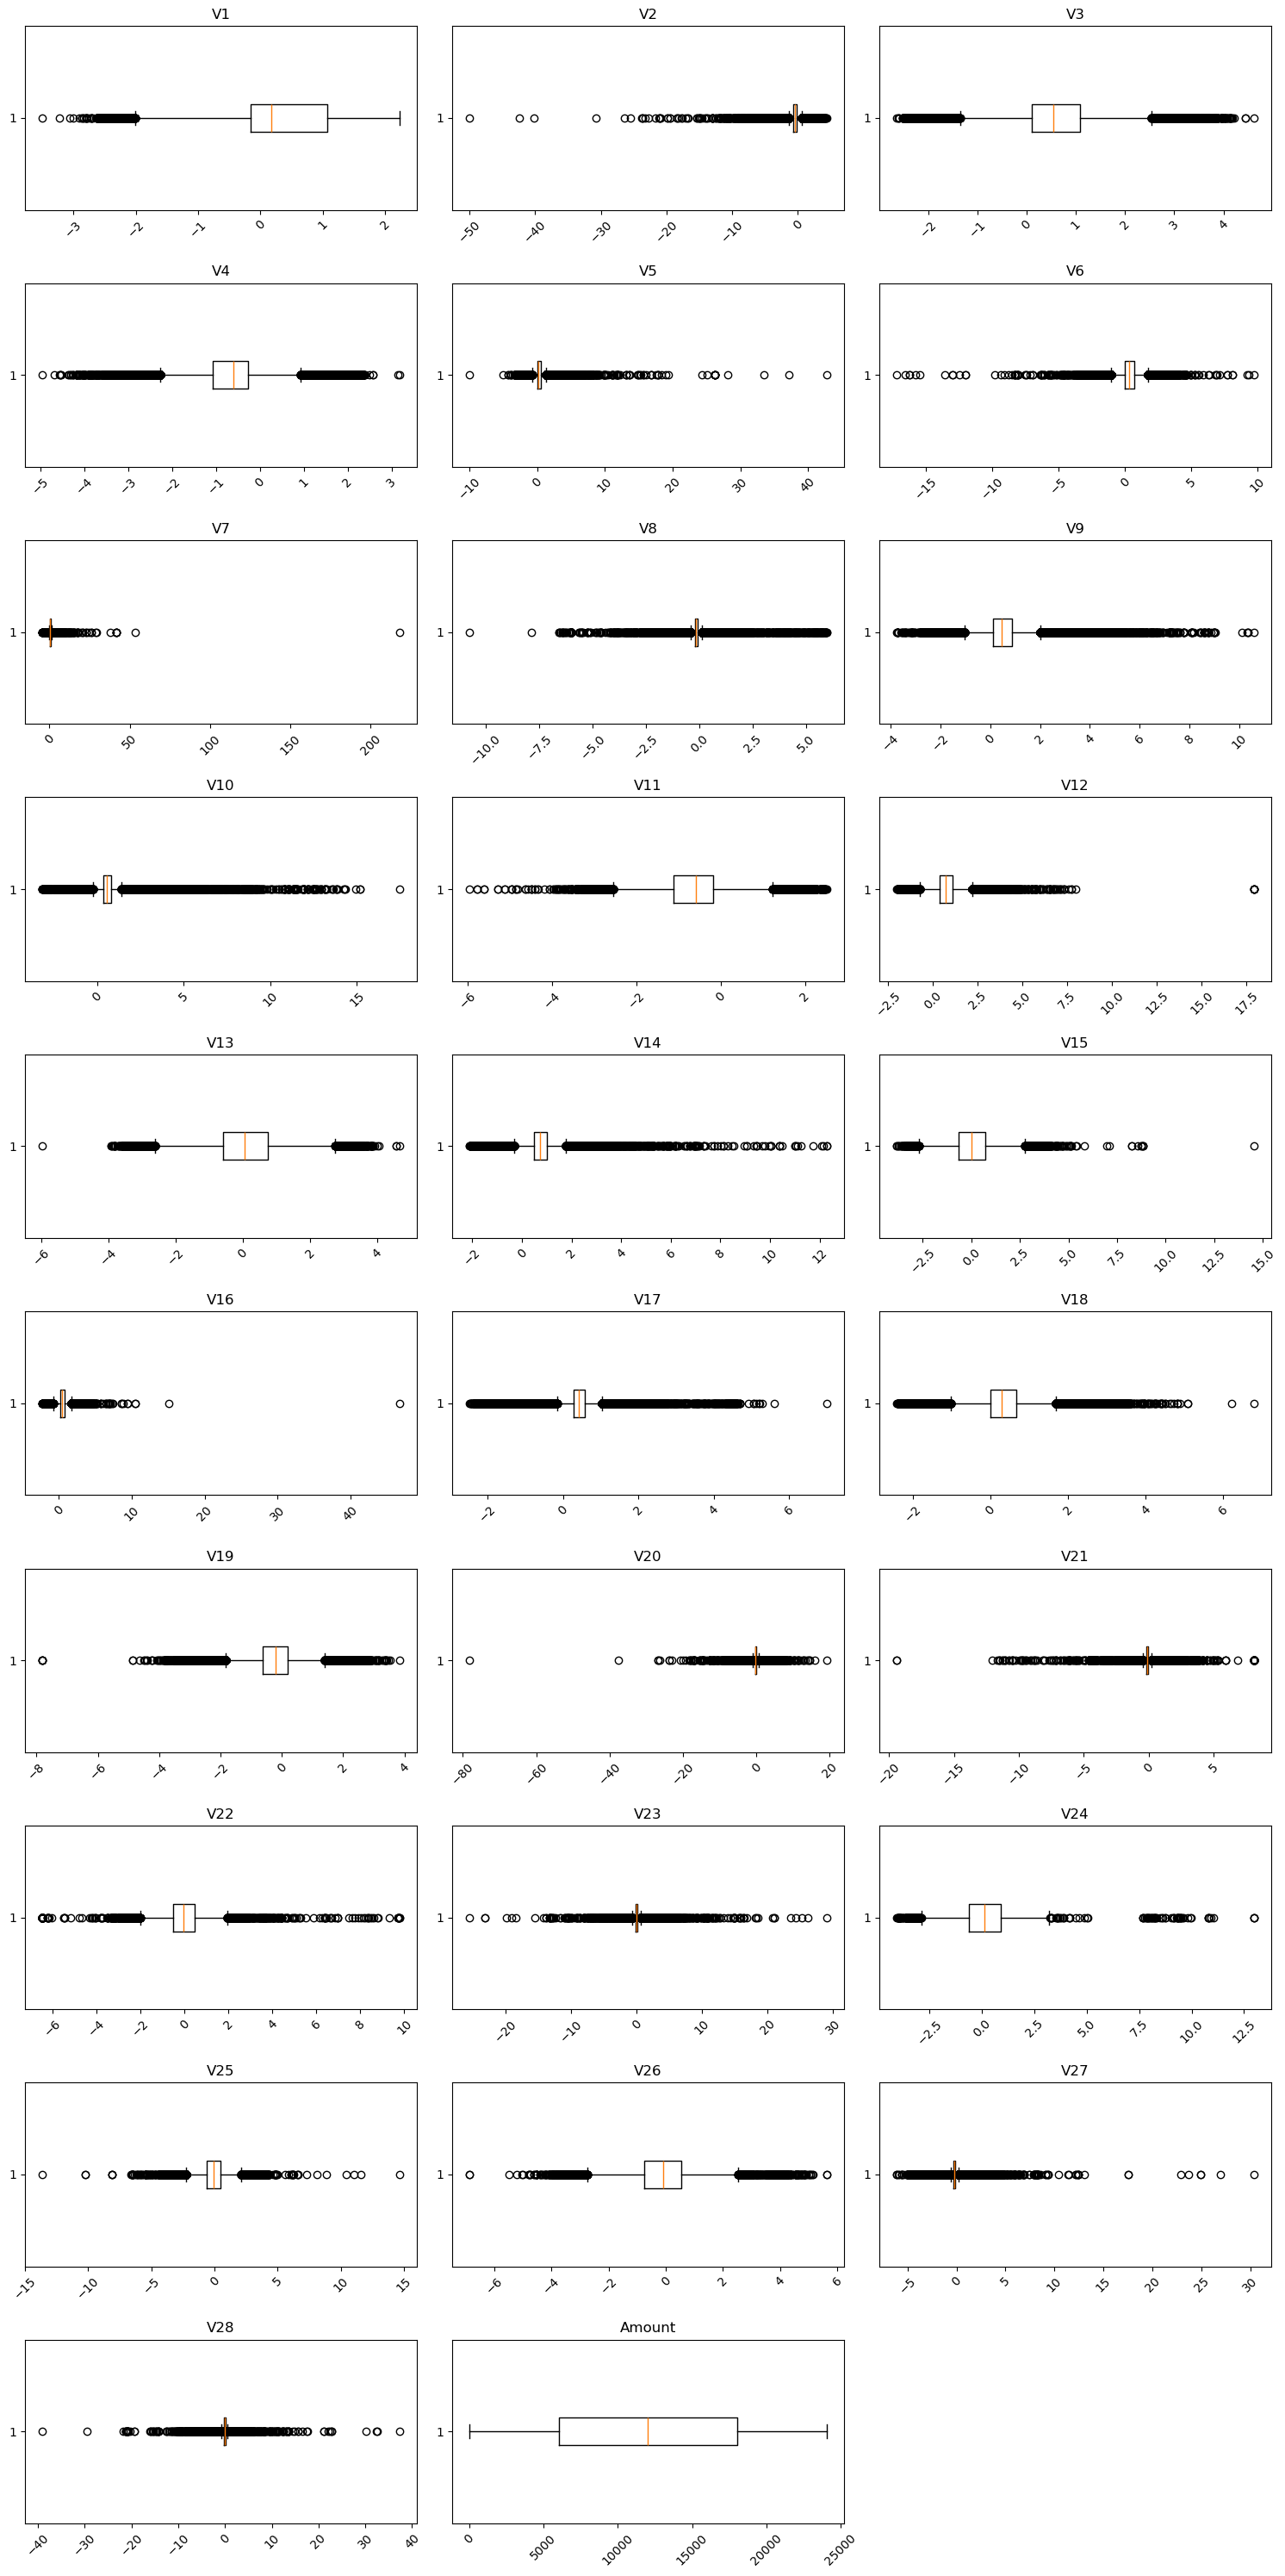

In [6]:
# Distribuția tuturor variabilelor

# Selectarea coloanelor numerice
df_plot=df.drop(['id','Class'], axis=1)
num_cols = df_plot.select_dtypes(include=[np.number]).columns

# Definirea dimensiunii figurii și subgraficul
n_cols = 3  # coloane în grid
n_rows = int(np.ceil(len(num_cols) / n_cols))  # rânduri calculate automat
fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, n_rows*3))

# Flatten pentru iterație ușoară
axes = axes.flatten()

# Creare boxplot pentru fiecare caracteristică numerică
for i, col in enumerate(num_cols):
    axes[i].boxplot(df_plot[col],orientation='horizontal')
    axes[i].set_title(col)
    axes[i].tick_params(axis='x', rotation=45)

# Ascundere subploturile goale dacă există
for j in range(i+1, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()



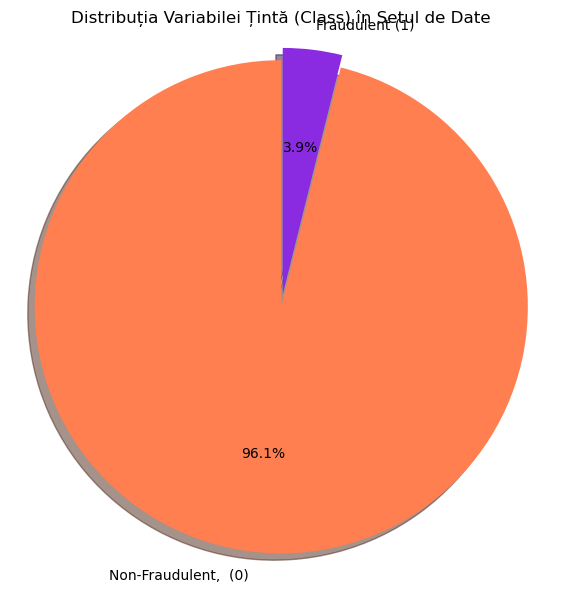

Distribuția exactă a claselor:
Class
0    144180
1      5820
Name: count, dtype: int64
Total înregistrări: 150000


In [7]:
outcome_counts = df['Class'].value_counts()

labels = ['Non-Fraudulent,  (0)', 'Fraudulent (1)']
sizes = outcome_counts.values
colors = ['#FF7F50', '#8A2BE2'] 
explode = (0.05, 0) 

plt.figure(figsize=(7, 7))
plt.pie(sizes, explode=explode, labels=labels, colors=colors, autopct='%1.1f%%',
        shadow=True, startangle=90)
plt.title('Distribuția Variabilei Țintă (Class) în Setul de Date')
plt.axis('equal') 
plt.show()


print("Distribuția exactă a claselor:")
print(outcome_counts)
print(f"Total înregistrări: {df.shape[0]}")


## Prelucram datele si incarcam librariile necesare

In [8]:
import numpy as np
import pandas as pd
from scipy.stats import median_abs_deviation
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

X = df.drop(columns=["Class", "id"])
Y = df["Class"]  # 0 = normal, 1 = fraud

Empirical_Fraud_Rate = df["Class"].mean()

## Robust Z-Score:

In [9]:
# Robust Z-score
median = X.median()
mad = median_abs_deviation(X, axis=0)
robust_z = (X - median) / mad
robust_z = robust_z.replace([np.inf, -np.inf], 0)

# Aggregate across features
row_score = robust_z.abs().mean(axis=1) 

# Threshold
z_threshold = np.quantile(row_score,1 - Empirical_Fraud_Rate) 

y_pred_z = (row_score > z_threshold).astype(int)

## Evaluare

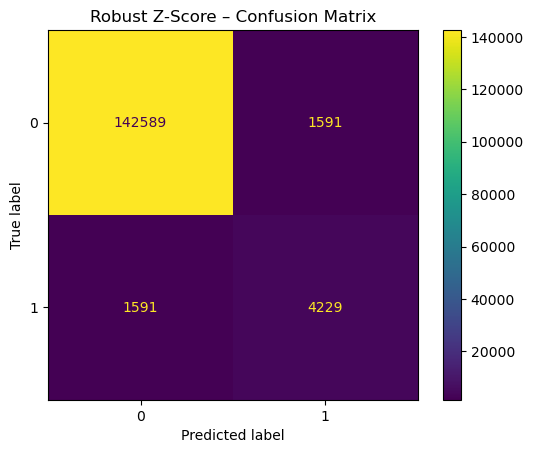

In [10]:
cm_z = confusion_matrix(Y, y_pred_z)
disp_z = ConfusionMatrixDisplay(cm_z)
disp_z.plot()
plt.title("Robust Z-Score – Confusion Matrix")
plt.show()

In [11]:
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.metrics import precision_recall_curve, auc

# ROC AUC
roc_auc_mad = roc_auc_score(Y, row_score)

# Precision-Recall curve
precision_mad, recall_mad, _ = precision_recall_curve(Y, row_score)
pr_auc_mad = auc(recall_mad, precision_mad)

print("Robust-Z ROC AUC:", roc_auc_mad)
print("Robust-Z PR AUC:", pr_auc_mad)

Robust-Z ROC AUC: 0.9818970583258138
Robust-Z PR AUC: 0.7594170070329411


<Figure size 640x480 with 0 Axes>

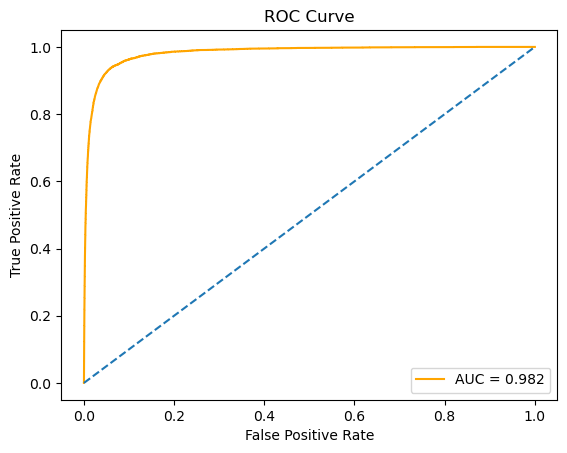

In [16]:
fpr, tpr, _ = roc_curve(Y, row_score)

plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {roc_auc_mad:.3f}",color="orange")
plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

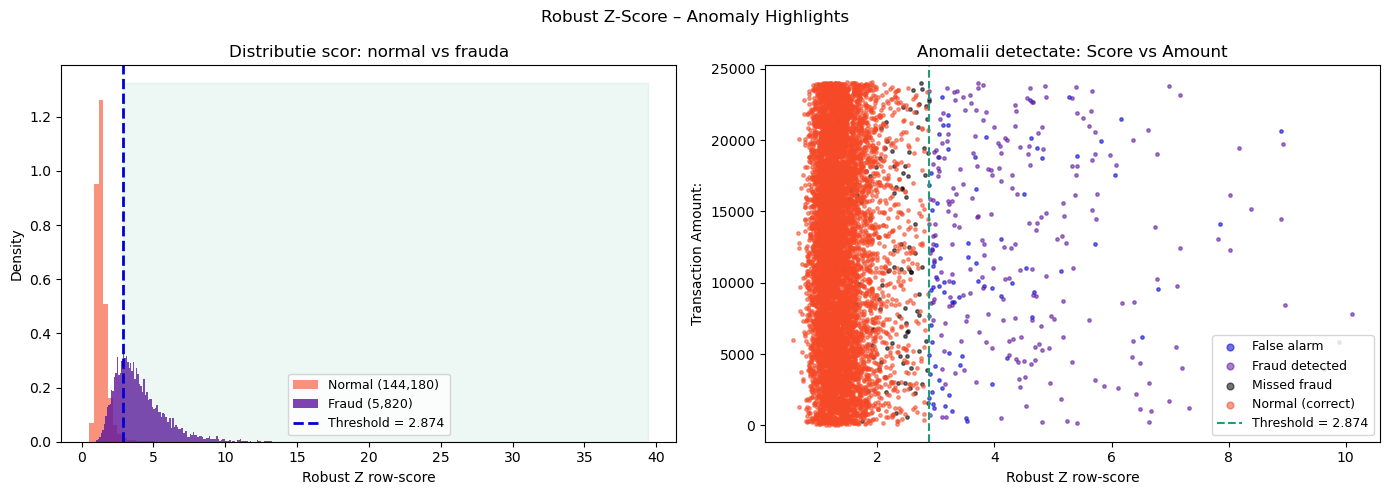


 Top 10 DETECTED frauds (Robust-Z)
    ID  Robust-Z score   Amount  True class
139299       13.229763 12106.04           1
 59500       13.180105  4433.01           1
 11976       13.085282 21546.03           1
 29987       12.988525  6378.16           1
  3521       12.882813  7964.56           1
 46558       12.803679  3578.25           1
 11376       12.451044 23992.99           1
114117       12.402338  3961.38           1
 96803       12.328246 13417.44           1
127069       12.302832 23262.01           1

 5 FALSE ALARMS (tranzactii legitimate considerate frauda)
    ID  Robust-Z score   Amount  True class
 18383       39.459902  9242.23           0
113818       16.655870 19170.63           0
 99308       12.749206  2864.57           0
 49580       12.210091  8763.15           0
  1442       11.038813 18450.66           0

 5 MISSED FRAUDS (tranzactii frauda care nu au fost prinse)
    ID  Robust-Z score   Amount  True class
 91903        1.032335  2373.32           1
 12747 

In [46]:
df_viz_z = df.copy()
df_viz_z["score"] = row_score.values
df_viz_z["pred"]  = y_pred_z.values
df_viz_z["label"] = "Normal (correct)"
df_viz_z.loc[(df_viz_z["pred"]==1)&(df_viz_z["Class"]==1), "label"] = "Fraud detected"
df_viz_z.loc[(df_viz_z["pred"]==1)&(df_viz_z["Class"]==0), "label"] = "False alarm"
df_viz_z.loc[(df_viz_z["pred"]==0)&(df_viz_z["Class"]==1), "label"] = "Missed fraud"

color_map = {
    "Normal (correct)": "#F54927",
    "Fraud detected": "#60159E",
    "False alarm":    "#0100D1",
    "Missed fraud":   "#000000",
}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Robust Z-Score – Anomaly Highlights")

# Score distribution
axes[0].hist(df_viz_z.loc[df_viz_z["Class"]==0, "score"], bins=120,
             color="#F54927", alpha=0.6, label="Normal (144,180)", density=True)
axes[0].hist(df_viz_z.loc[df_viz_z["Class"]==1, "score"], bins=120,
             color="#60159E", alpha=0.8, label="Fraud (5,820)", density=True)
axes[0].axvline(z_threshold, color="#0100D1", linewidth=2, linestyle="--",
                label=f"Threshold = {z_threshold:.3f}")
ymax = axes[0].get_ylim()[1]
axes[0].fill_betweenx([0, ymax], z_threshold, df_viz_z["score"].max(),
                      color="#1D9E75", alpha=0.08)
axes[0].set_xlabel("Robust Z row-score")
axes[0].set_ylabel("Density")
axes[0].set_title("Distributie scor: normal vs frauda")
axes[0].legend(fontsize=9)

sample = df_viz_z.sample(n=min(8000, len(df_viz_z)), random_state=42)
for lbl, grp in sample.groupby("label"):
    axes[1].scatter(grp["score"], grp["Amount"],
                    c=color_map[lbl], s=6, alpha=0.55, label=lbl, rasterized=True)
axes[1].axvline(z_threshold, color="#1D9E75", linewidth=1.5, linestyle="--",
                label=f"Threshold = {z_threshold:.3f}")
axes[1].set_xlabel("Robust Z row-score")
axes[1].set_ylabel("Transaction Amount:")
axes[1].set_title("Anomalii detectate: Score vs Amount")
axes[1].legend(fontsize=9, markerscale=2)

plt.tight_layout()
plt.show()

# Sample tables
print("\n Top 10 DETECTED frauds (Robust-Z)")
top = (df_viz_z[df_viz_z["label"]=="Fraud detected"]
       .nlargest(10,"score")[["id","score","Amount","Class"]])
top.columns = ["ID","Robust-Z score","Amount","True class"]
print(top.to_string(index=False))

print("\n 5 FALSE ALARMS (tranzactii legitimate considerate frauda)")
fa = (df_viz_z[df_viz_z["label"]=="False alarm"]
      .nlargest(5,"score")[["id","score","Amount","Class"]])
fa.columns = ["ID","Robust-Z score","Amount","True class"]
print(fa.to_string(index=False))

print("\n 5 MISSED FRAUDS (tranzactii frauda care nu au fost prinse)")
ms = (df_viz_z[df_viz_z["label"]=="Missed fraud"]
      .nsmallest(5,"score")[["id","score","Amount","Class"]])
ms.columns = ["ID","Robust-Z score","Amount","True class"]
print(ms.to_string(index=False))


## Scalam datele folosind sklearn

In [21]:
from sklearn.preprocessing import StandardScaler, RobustScaler

# scaler = StandardScaler() 
scaler = RobustScaler()
X_scaled = scaler.fit_transform(X)

## Isolation Forest

In [22]:
iso = IsolationForest(
    n_estimators=100,
    contamination=Empirical_Fraud_Rate,  
    random_state=42
)

y_iforest = iso.fit_predict(X_scaled)
y_pred_if = np.where(y_iforest == -1, 1, 0)

## Evaluare

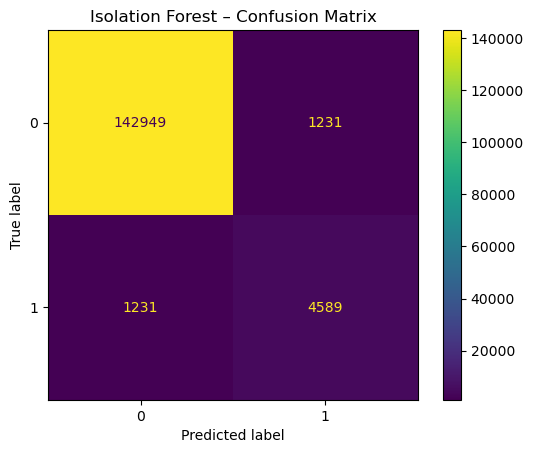

In [23]:
cm_if = confusion_matrix(Y, y_pred_if)
disp_if = ConfusionMatrixDisplay(cm_if)
disp_if.plot()
plt.title("Isolation Forest – Confusion Matrix")
plt.show()

In [24]:
# anomaly score
iso_scores = -iso.decision_function(X_scaled)

# ROC AUC
roc_auc_iso = roc_auc_score(Y, iso_scores)

# PR AUC
precision_iso, recall_iso, _ = precision_recall_curve(Y, iso_scores)
pr_auc_iso = auc(recall_iso, precision_iso)

print("Isolation Forest ROC AUC:", roc_auc_iso)
print("Isolation Forest PR AUC:", pr_auc_iso)

Isolation Forest ROC AUC: 0.9729911291202912
Isolation Forest PR AUC: 0.8626686726344606


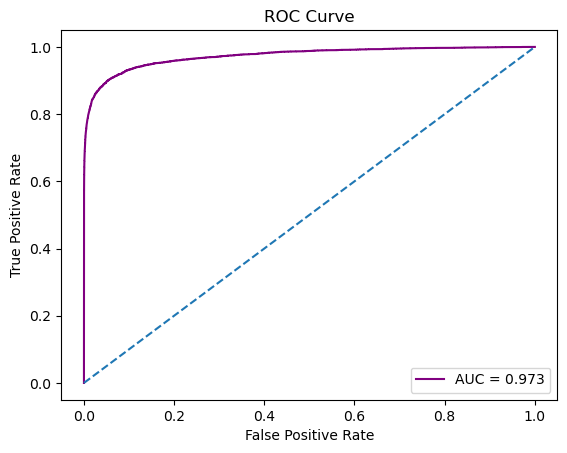

In [25]:
fpr, tpr, _ = roc_curve(Y, iso_scores)

plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {roc_auc_iso:.3f}",color="purple")
plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

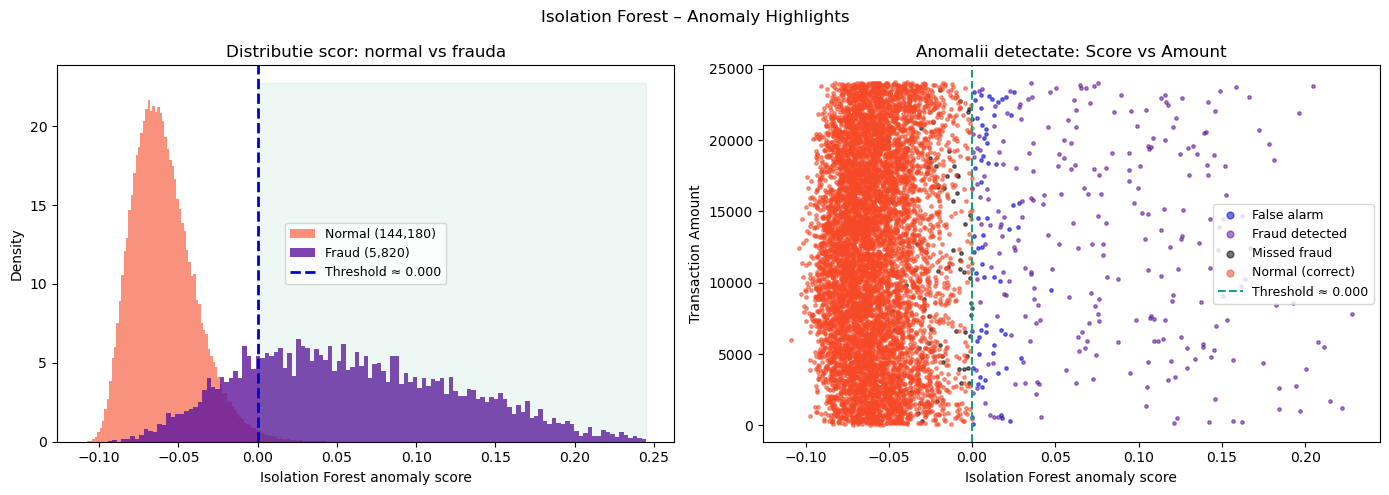


 Top 10 DETECTED frauds (Isolation Forest) 
    ID  IF score   Amount  True class
146864  0.245008 21445.51           1
144199  0.242555  4193.88           1
 96803  0.242323 13417.44           1
 99014  0.242016  4581.39           1
 59500  0.241967  4433.01           1
 15418  0.240154  6148.21           1
139299  0.240105 12106.04           1
 11976  0.239054 21546.03           1
114778  0.238625 10017.10           1
 26515  0.237560 19921.10           1

 5 FALSE ALARMS 
    ID  IF score   Amount  True class
 66246  0.073198  6895.57           0
140144  0.064525  1077.58           0
106812  0.063278  2267.15           0
 67056  0.062529 21844.04           0
147599  0.060825   972.50           0

 5 MISSED FRAUDS 
   ID  IF score   Amount  True class
20535 -0.094446 16260.35           1
26792 -0.090057  7478.40           1
59313 -0.089678  3237.40           1
88374 -0.085003  4930.70           1
91903 -0.084522  2373.32           1


In [45]:
# ── Isolation Forest: Anomaly Highlights ──────────────────────
df_viz_if = df.copy()
df_viz_if["score"] = iso_scores
df_viz_if["pred"]  = y_pred_if
df_viz_if["label"] = "Normal (correct)"
df_viz_if.loc[(df_viz_if["pred"]==1)&(df_viz_if["Class"]==1), "label"] = "Fraud detected"
df_viz_if.loc[(df_viz_if["pred"]==1)&(df_viz_if["Class"]==0), "label"] = "False alarm"
df_viz_if.loc[(df_viz_if["pred"]==0)&(df_viz_if["Class"]==1), "label"] = "Missed fraud"

color_map = {
    "Normal (correct)": "#F54927",
    "Fraud detected": "#60159E",
    "False alarm":    "#0100D1",
    "Missed fraud":   "#000000",
}


fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Isolation Forest – Anomaly Highlights")

axes[0].hist(df_viz_if.loc[df_viz_if["Class"]==0, "score"], bins=120,
             color="#F54927", alpha=0.6, label="Normal (144,180)", density=True)
axes[0].hist(df_viz_if.loc[df_viz_if["Class"]==1, "score"], bins=120,
             color="#60159E", alpha=0.8, label="Fraud (5,820)", density=True)
if_threshold = np.quantile(iso_scores, 1 - Empirical_Fraud_Rate)
axes[0].axvline(if_threshold, color="#0100D1", linewidth=2, linestyle="--",
                label=f"Threshold ≈ {if_threshold:.3f}")
ymax = axes[0].get_ylim()[1]
axes[0].fill_betweenx([0, ymax], if_threshold, df_viz_if["score"].max(),
                      color="#1D9E75", alpha=0.08)
axes[0].set_xlabel("Isolation Forest anomaly score")
axes[0].set_ylabel("Density")
axes[0].set_title("Distributie scor: normal vs frauda")
axes[0].legend(fontsize=9)

sample_if = df_viz_if.sample(n=min(8000, len(df_viz_if)), random_state=42)
for lbl, grp in sample_if.groupby("label"):
    axes[1].scatter(grp["score"], grp["Amount"],
                    c=color_map[lbl], s=6, alpha=0.55, label=lbl, rasterized=True)
axes[1].axvline(if_threshold, color="#1D9E75", linewidth=1.5, linestyle="--",
                label=f"Threshold ≈ {if_threshold:.3f}")
axes[1].set_xlabel("Isolation Forest anomaly score")
axes[1].set_ylabel("Transaction Amount")
axes[1].set_title("Anomalii detectate: Score vs Amount")
axes[1].legend(fontsize=9, markerscale=2)

plt.tight_layout()
plt.show()

print("\n Top 10 DETECTED frauds (Isolation Forest) ")
top = (df_viz_if[df_viz_if["label"]=="Fraud detected"]
       .nlargest(10,"score")[["id","score","Amount","Class"]])
top.columns = ["ID","IF score","Amount","True class"]
print(top.to_string(index=False))

print("\n 5 FALSE ALARMS ")
fa = (df_viz_if[df_viz_if["label"]=="False alarm"]
      .nlargest(5,"score")[["id","score","Amount","Class"]])
fa.columns = ["ID","IF score","Amount","True class"]
print(fa.to_string(index=False))

print("\n 5 MISSED FRAUDS ")
ms = (df_viz_if[df_viz_if["label"]=="Missed fraud"]
      .nsmallest(5,"score")[["id","score","Amount","Class"]])
ms.columns = ["ID","IF score","Amount","True class"]
print(ms.to_string(index=False))


## Local Outlier Factor (LOF)

In [32]:
warnings.filterwarnings('ignore')
lof = LocalOutlierFactor(
    n_neighbors=580, # Observatie: Costul compational este foarte ridicat.
    contamination=Empirical_Fraud_Rate,
    n_jobs=-1 # Ne asiguram ca foloseste toate Procesoarele Logice ale CPU-lui
)

y_lof = lof.fit_predict(X_scaled)
y_pred_lof = np.where(y_lof == -1, 1, 0)

## Evaluare

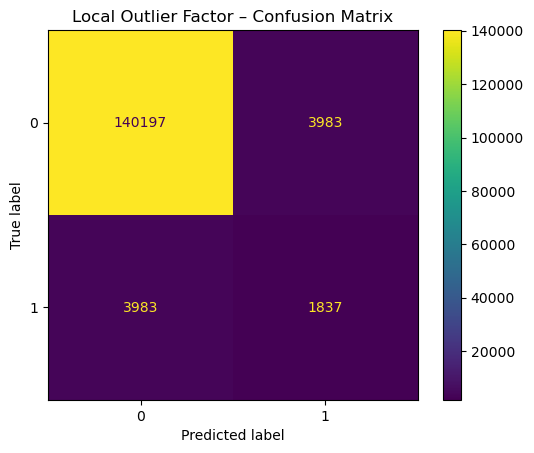

In [28]:
cm_lof = confusion_matrix(Y, y_pred_lof)
disp_lof = ConfusionMatrixDisplay(cm_lof)
disp_lof.plot()
plt.title("Local Outlier Factor – Confusion Matrix")
plt.show()

In [29]:
lof_scores = -lof.negative_outlier_factor_

# ROC AUC
roc_auc_lof = roc_auc_score(Y, lof_scores)

# PR AUC
precision_lof, recall_lof, _ = precision_recall_curve(Y, lof_scores)
pr_auc_lof = auc(recall_lof, precision_lof)

print("LOF ROC AUC:", roc_auc_lof)
print("LOF PR AUC:", pr_auc_lof)

LOF ROC AUC: 0.7144064812073874
LOF PR AUC: 0.18480282588492675


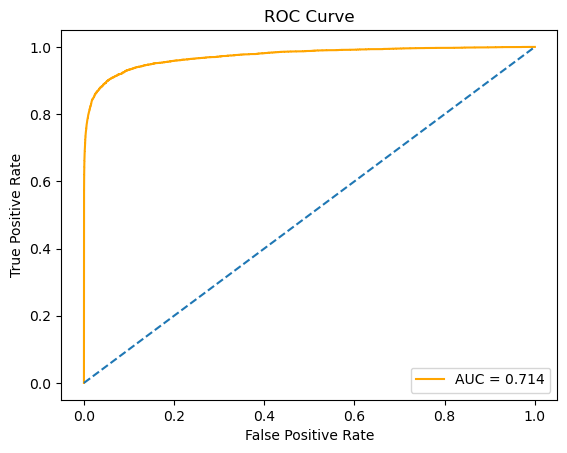

In [30]:
fpr, tpr, _ = roc_curve(Y, iso_scores)

plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {roc_auc_lof:.3f}",color="orange")
plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

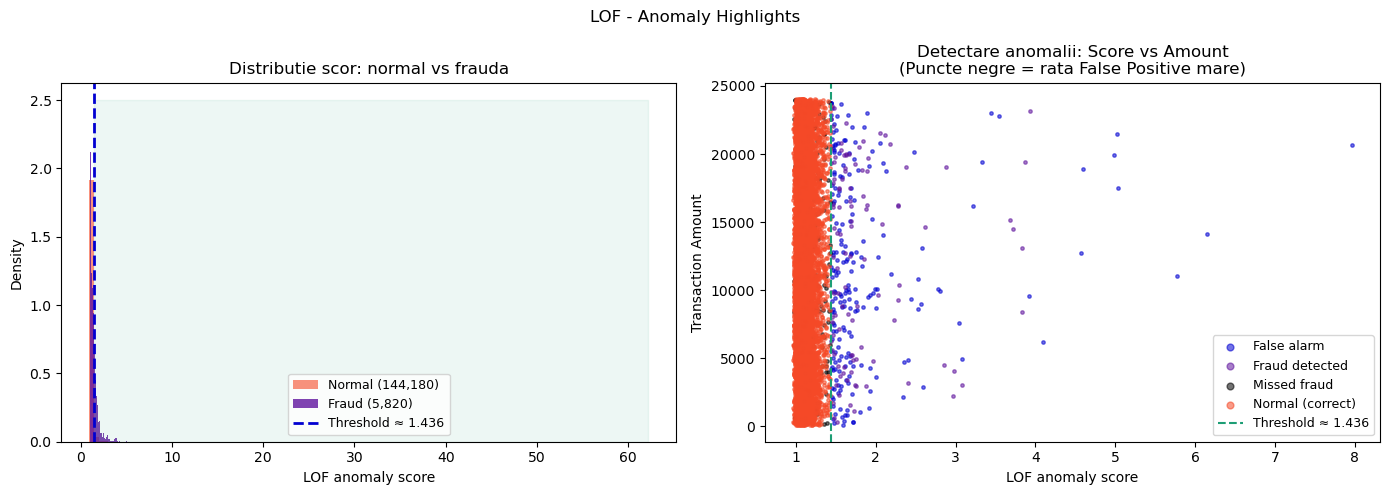


 Top 10 DETECTED frauds (LOF)
    ID  LOF score   Amount  True class
 69337   5.047026  8810.01           1
 25845   4.842184 12595.13           1
109359   4.621156  7888.61           1
133379   4.361803 19699.32           1
 73332   4.325847  7475.30           1
129267   4.305816 10376.40           1
 36260   4.301656  8247.68           1
 82893   4.274268 15030.30           1
 29987   4.234676  6378.16           1
   625   4.226327  4057.07           1

 5 FALSE ALARMS
    ID  LOF score   Amount  True class
 18383  62.195880  9242.23           0
113818  17.646788 19170.63           0
 57970  14.591231  5382.02           0
147087  13.638531 17700.34           0
 99308  11.281684  2864.57           0

 5 MISSED FRAUDS
    ID  LOF score   Amount  True class
 30615   0.979408  3338.52           1
 40402   0.979479 20541.05           1
  1217   0.979676 22981.50           1
107582   0.979835  8378.08           1
  1363   0.980091  3039.73           1


In [47]:
# ── LOF: Anomaly Highlights ────────────────────────────────────
df_viz_lof = df.copy()
df_viz_lof["score"] = lof_scores
df_viz_lof["pred"]  = y_pred_lof
df_viz_lof["label"] = "Normal (correct)"
df_viz_lof.loc[(df_viz_lof["pred"]==1)&(df_viz_lof["Class"]==1), "label"] = "Fraud detected"
df_viz_lof.loc[(df_viz_lof["pred"]==1)&(df_viz_lof["Class"]==0), "label"] = "False alarm"
df_viz_lof.loc[(df_viz_lof["pred"]==0)&(df_viz_lof["Class"]==1), "label"] = "Missed fraud"

color_map = {
    "Normal (correct)": "#F54927",
    "Fraud detected": "#60159E",
    "False alarm":    "#0100D1",
    "Missed fraud":   "#000000",
}


fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("LOF - Anomaly Highlights")

axes[0].hist(df_viz_lof.loc[df_viz_lof["Class"]==0, "score"], bins=120,
             color="#F54927", alpha=0.6, label="Normal (144,180)", density=True)
axes[0].hist(df_viz_lof.loc[df_viz_lof["Class"]==1, "score"], bins=120,
             color="#60159E", alpha=0.8, label="Fraud (5,820)", density=True)
lof_threshold = np.quantile(lof_scores, 1 - Empirical_Fraud_Rate)
axes[0].axvline(lof_threshold, color="#0100D1", linewidth=2, linestyle="--",
                label=f"Threshold ≈ {lof_threshold:.3f}")
ymax = axes[0].get_ylim()[1]
axes[0].fill_betweenx([0, ymax], lof_threshold, df_viz_lof["score"].max(),
                      color="#1D9E75", alpha=0.08)
axes[0].set_xlabel("LOF anomaly score")
axes[0].set_ylabel("Density")
axes[0].set_title("Distributie scor: normal vs frauda")
axes[0].legend(fontsize=9)

sample_lof = df_viz_lof.sample(n=min(8000, len(df_viz_lof)), random_state=42)
for lbl, grp in sample_lof.groupby("label"):
    axes[1].scatter(grp["score"], grp["Amount"],
                    c=color_map[lbl], s=6, alpha=0.55, label=lbl, rasterized=True)
axes[1].axvline(lof_threshold, color="#1D9E75", linewidth=1.5, linestyle="--",
                label=f"Threshold ≈ {lof_threshold:.3f}")
axes[1].set_xlabel("LOF anomaly score")
axes[1].set_ylabel("Transaction Amount")
axes[1].set_title("Detectare anomalii: Score vs Amount\n(Puncte negre = rata False Positive mare)")
axes[1].legend(fontsize=9, markerscale=2)

plt.tight_layout()
plt.show()

print("\n Top 10 DETECTED frauds (LOF)")
top = (df_viz_lof[df_viz_lof["label"]=="Fraud detected"]
       .nlargest(10,"score")[["id","score","Amount","Class"]])
top.columns = ["ID","LOF score","Amount","True class"]
print(top.to_string(index=False))

print("\n 5 FALSE ALARMS")
fa = (df_viz_lof[df_viz_lof["label"]=="False alarm"]
      .nlargest(5,"score")[["id","score","Amount","Class"]])
fa.columns = ["ID","LOF score","Amount","True class"]
print(fa.to_string(index=False))

print("\n 5 MISSED FRAUDS")
ms = (df_viz_lof[df_viz_lof["label"]=="Missed fraud"]
      .nsmallest(5,"score")[["id","score","Amount","Class"]])
ms.columns = ["ID","LOF score","Amount","True class"]
print(ms.to_string(index=False))


## Comparam rezultatele

In [50]:
results = pd.DataFrame({
    "Method": ["Robust Z", "Isolation Forest", "LOF"],
    "True Positives(TP)": [cm_z[1,1], cm_if[1,1], cm_lof[1,1]],
    "False Positives(FP)": [cm_z[0,1], cm_if[0,1], cm_lof[0,1]],
    "False Negatives(FN)": [cm_z[1,0], cm_if[1,0], cm_lof[1,0]],
    "True Negatives(TN)": [cm_z[0,0], cm_if[0,0], cm_lof[0,0]]
})

results

,Method,True Positives(TP),False Positives(FP),False Negatives(FN),True Negatives(TN)
0,Robust Z,4229,1591,1591,142589
1,Isolation Forest,4589,1231,1231,142949
2,LOF,1837,3983,3983,140197


          Method   Recall       F1  Precision
        Robust Z 0.726632 0.726632   0.726632
Isolation Forest 0.788488 0.788488   0.788488
             LOF 0.315636 0.315636   0.315636


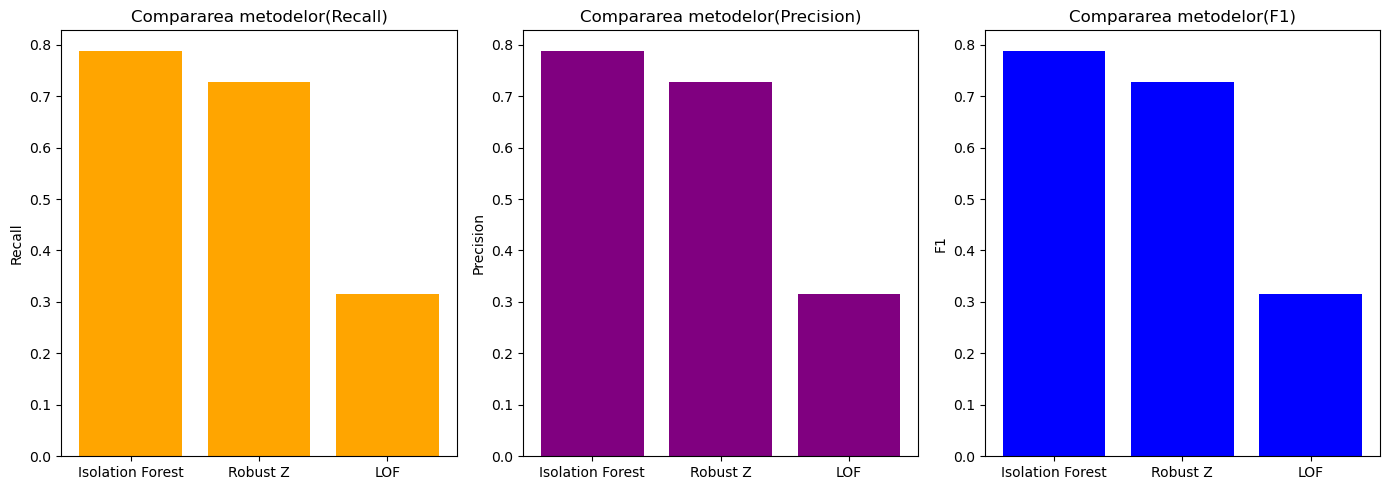

In [78]:
import pandas as pd

results = pd.DataFrame({
    "Method": ["Robust Z", "Isolation Forest", "LOF"],
    "TP": [cm_z[1,1], cm_if[1,1], cm_lof[1,1]],
    "FP": [cm_z[0,1], cm_if[0,1], cm_lof[0,1]],
    "FN": [cm_z[1,0], cm_if[1,0], cm_lof[1,0]],
    "TN": [cm_z[0,0], cm_if[0,0], cm_lof[0,0]]
})

results["Recall"] = results["TP"] / (results["TP"] + results["FN"])
results["Precision"] = results["TP"] / (results["TP"] + results["FP"])
results["Accuracy"] = (results["TP"] + results["TN"]) / (
    results["TP"] + results["FP"] + results["FN"] + results["TN"]
)
results["F1"] = 2 * (
    (results["Precision"] * results["Recall"]) /
    (results["Precision"] + results["Recall"])
)

results.round(4)

results_sorted = results.sort_values("Recall", ascending=False)
print(results[["Method", "Recall","F1","Precision"]].to_string(index=False))

fig, axes = plt.subplots(1, 3, figsize=(14, 5))

axes[0].bar(
    results_sorted["Method"],
    results_sorted["Recall"],
    color="orange"
)
axes[0].set_ylabel("Recall")
axes[0].set_title("Compararea metodelor(Recall)")

axes[1].bar(
    results_sorted["Method"],
    results_sorted["Precision"],
    color="purple"
)
axes[1].set_ylabel("Precision")
axes[1].set_title("Compararea metodelor(Precision)")

axes[2].bar(
    results_sorted["Method"],
    results_sorted["F1"],
    color="blue"
)
axes[2].set_ylabel("F1")
axes[2].set_title("Compararea metodelor(F1)")



plt.tight_layout()
plt.show()

<h2 style="background-color: Coral; color: FloralWhite; padding: 8.75px; border-radius: 2px; text-align: Left; font-family: 'Arial', serif;">
<b>Concluzii:</b> 
<b>Observatie: </b> deoarece rata de frauda (3.88%) este cunoscuta, metodele <b> Isolation Forest </b> si <b> Robust Z </b> prezinta performante apropiate de scenariul ideal.
<h3 style="background-color: BlueViolet; color: FloralWhite; padding: 8.75px; border-radius: 10px; text-align: Left; font-family: 'Arial', serif;">
A. <b> Isolation Forest: </b> <br>
Prezinta cea mai buna performanta generala, cu un scor F1 de aproximativ $~0.788$. Metoda functioneaza eficient pe seturi de date mari si multi-variabile. In plus, are un cost computational relativ redus: $ O(n \log n)\ $. <br>
B. <b> Robust Z: </b> <br>
Inregistreaza o performanta buna, cu un scor F1 de aproximativ $~0.724$. Totusi, metoda este limitata deoarece nu poate analiza direct relatii multi-variabile. O tranzactie poate parea normala pentru fiecare caracteristica individual, dar poate deveni anomala in combinatie cu alte caracteristici. Cu un cost computational redus: $ O(n \log n)\ $, metoda ramane relevanta pentru analiza si studiu. <br>
C. <b> Local Outlier Factor: </b> <br>
Performanta obtinuta este scazuta, iar costul computational este ridicat. Parametrul n_neighbors a fost ajustat fata de valoarea implicita de 20, deoarece modelul avea initial o performanta cu aproximativ 50% mai slaba. Avand un cost computational aproximativ de $ O(n^2)\ $, timpul de calcul si consumul de memorie al CPU devin prea mari pentru a justifica performanta obtinuta. Din cauza dimensiunii setului de date si a densitatii ridicate a datelor, metoda LOF fara abordare semi-supravegheata nu este potrivita pentru acest set de date. <br>
</h3>
</h2>